In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("crop_prices.csv")

df.head()

,State,District,Market,Commodity,Variety,Grade,Arrival_Date,Min_x0020_Price,Max_x0020_Price,Modal_x0020_Price
0,Punjab,Mohali,Kharar APMC,Onion,Other,Non-FAQ,13/03/2026,1500,2000,1700.0
1,Punjab,Mohali,Kharar APMC,Peas Wet,Peas Wet,Local,13/03/2026,1500,3000,2500.0
2,Punjab,Mohali,Kharar APMC,Pumpkin,Other,Local,13/03/2026,2000,2500,2200.0
3,Punjab,Mohali,Kharar APMC,Green Chilli,Green Chilly,Local,13/03/2026,7000,8000,7500.0
4,Madhya Pradesh,Badwani,Badwani(F&V) APMC,Green Chilli,Green Chilly,Local,13/03/2026,2500,2500,2500.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6924 entries, 0 to 6923
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   State              6924 non-null   object 
 1   District           6924 non-null   object 
 2   Market             6924 non-null   object 
 3   Commodity          6924 non-null   object 
 4   Variety            6924 non-null   object 
 5   Grade              6924 non-null   object 
 6   Arrival_Date       6924 non-null   object 
 7   Min_x0020_Price    6924 non-null   int64  
 8   Max_x0020_Price    6924 non-null   int64  
 9   Modal_x0020_Price  6924 non-null   float64
dtypes: float64(1), int64(2), object(7)
memory usage: 541.1+ KB


In [7]:
df.describe()

,Min_x0020_Price,Max_x0020_Price,Modal_x0020_Price
count,6924.000000,6924.000000,6924.000000
mean,4107.083911,4720.643703,4413.231297
std,4073.867255,4573.957716,4291.956992
min,100.000000,200.000000,200.000000
25%,2000.000000,2500.000000,2300.000000
50%,3200.000000,3800.000000,3500.000000
75%,5000.000000,5500.000000,5000.000000
max,75000.000000,95000.000000,80000.000000


In [8]:
df.isnull().sum()

,0
State,0
District,0
Market,0
Commodity,0
Variety,0
Grade,0
Arrival_Date,0
Min_x0020_Price,0
Max_x0020_Price,0
Modal_x0020_Price,0


In [10]:
df.shape

(6924, 10)

COLUMNS :

In [13]:
df.columns

Index(['State', 'District', 'Market', 'Commodity', 'Variety', 'Grade',
       'Arrival_Date', 'Min_x0020_Price', 'Max_x0020_Price',
       'Modal_x0020_Price'],
      dtype='object')

CATEGORICAL COLUMNS :

In [11]:
df.select_dtypes(include='object').describe()

,State,District,Market,Commodity,Variety,Grade,Arrival_Date
count,6924,6924,6924,6924,6924,6924,6924
unique,23,179,376,139,208,12,1
top,Tamil Nadu,Salem,RSPuram(Uzhavar Sandhai ) APMC,Tomato,Other,Local,13/03/2026
freq,4904,471,65,227,874,5217,6924


NUMERICAL COLUMNS :

In [12]:
df.select_dtypes(include='number').describe()

,Min_x0020_Price,Max_x0020_Price,Modal_x0020_Price
count,6924.000000,6924.000000,6924.000000
mean,4107.083911,4720.643703,4413.231297
std,4073.867255,4573.957716,4291.956992
min,100.000000,200.000000,200.000000
25%,2000.000000,2500.000000,2300.000000
50%,3200.000000,3800.000000,3500.000000
75%,5000.000000,5500.000000,5000.000000
max,75000.000000,95000.000000,80000.000000


Question 1
What is the distribution of crop prices?

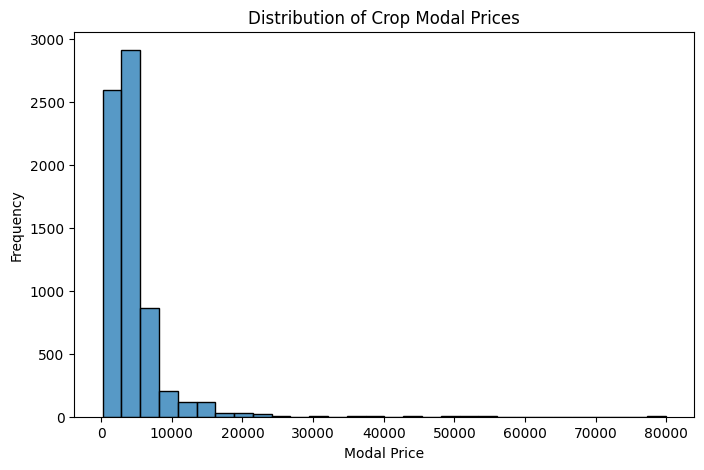

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df["Modal_x0020_Price"], bins=30)
plt.title("Distribution of Crop Modal Prices")
plt.xlabel("Modal Price")
plt.ylabel("Frequency")
plt.show()

Interpretation

The histogram shows how crop prices are distributed.
Most prices appear concentrated in a specific range, indicating typical market price levels, while extreme values represent unusually high or low prices.

Question 2
Which crops have the highest average price?

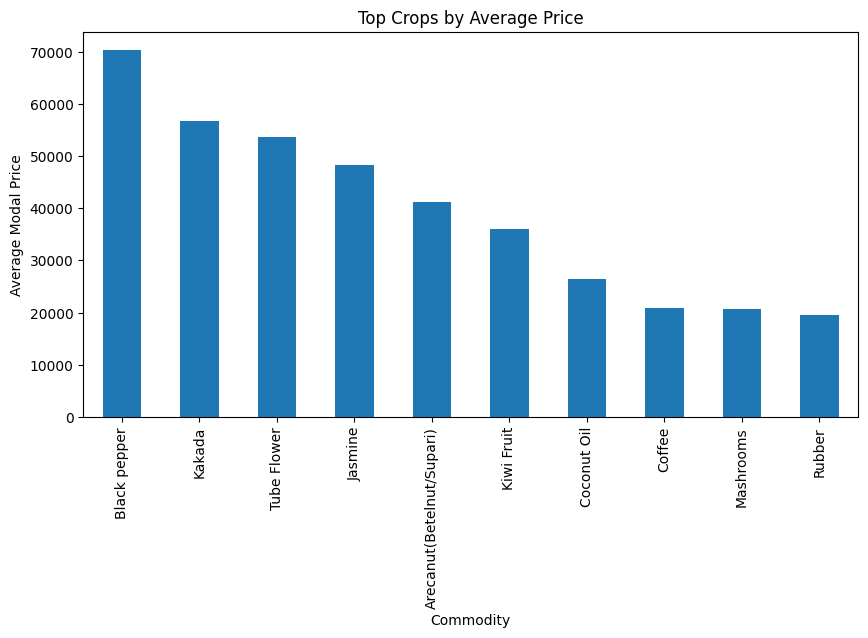

In [16]:
avg_price = df.groupby("Commodity")["Modal_x0020_Price"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
avg_price.head(10).plot(kind="bar")
plt.title("Top Crops by Average Price")
plt.ylabel("Average Modal Price")
plt.show()

Interpretation

This chart shows which crops are generally more expensive in the market.
High-value crops usually have higher demand or lower supply.

Question 3
How do minimum and maximum prices relate to modal price?

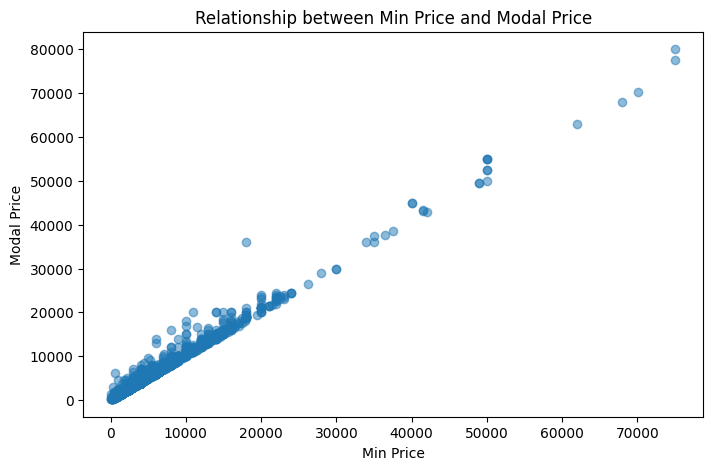

In [17]:
plt.figure(figsize=(8,5))
plt.scatter(df["Min_x0020_Price"], df["Modal_x0020_Price"], alpha=0.5)
plt.xlabel("Min Price")
plt.ylabel("Modal Price")
plt.title("Relationship between Min Price and Modal Price")
plt.show()

Interpretation

The scatter plot shows that modal prices tend to increase when minimum prices increase, indicating a positive relationship between these variables.

Question 4
What is the variation between minimum and maximum prices?

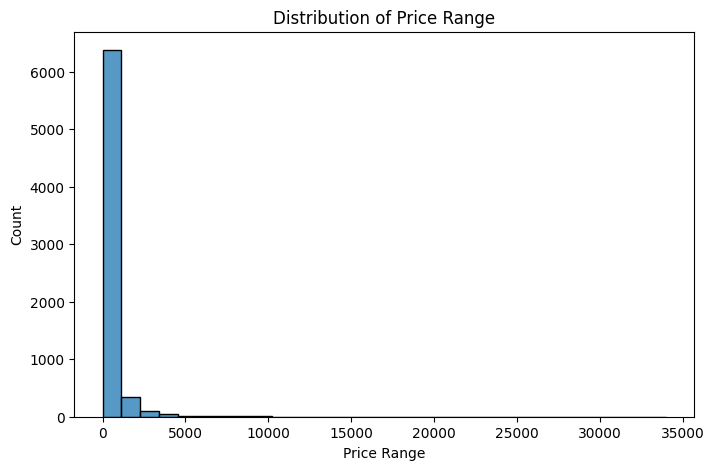

In [18]:
df["Price Range"] = df["Max_x0020_Price"] - df["Min_x0020_Price"]

plt.figure(figsize=(8,5))
sns.histplot(df["Price Range"], bins=30)
plt.title("Distribution of Price Range")
plt.show()

Interpretation

This plot shows how much prices fluctuate within a market.
Large ranges indicate high volatility, while small ranges suggest stable prices.

Question 5
Which states have the highest crop prices?

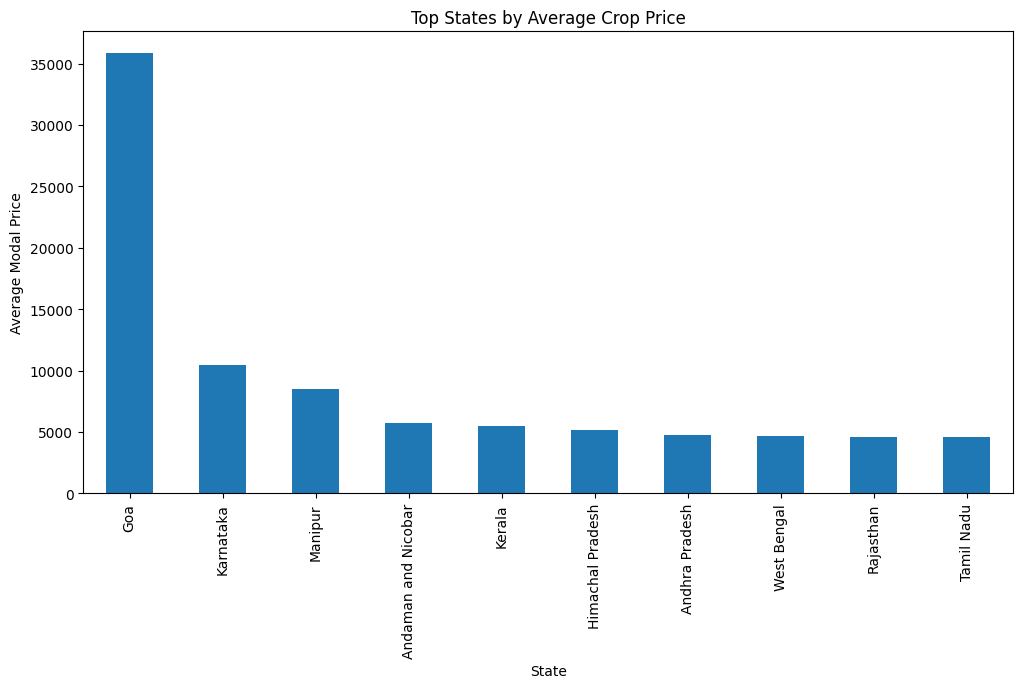

In [19]:
state_price = df.groupby("State")["Modal_x0020_Price"].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
state_price.head(10).plot(kind="bar")
plt.title("Top States by Average Crop Price")
plt.ylabel("Average Modal Price")
plt.show()

Interpretation

This chart highlights states where crop prices are generally higher.
Differences may be due to transportation costs, demand, or local production levels.

Question 6
Which markets report the highest prices?

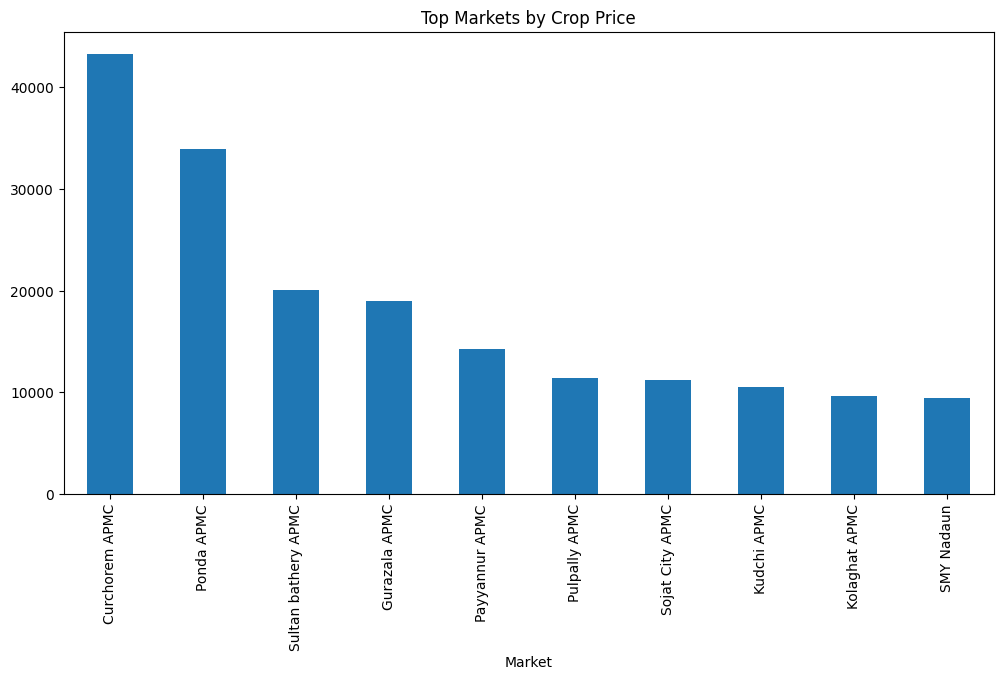

In [21]:
market_price = df.groupby("Market")["Modal_x0020_Price"].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
market_price.head(10).plot(kind="bar")
plt.title("Top Markets by Crop Price")
plt.show()

Interpretation

Certain markets consistently report higher prices, possibly due to larger demand or urban market influence.

Question 7
How does the distribution of crop prices vary across different arrival dates?

<Figure size 1200x600 with 0 Axes>

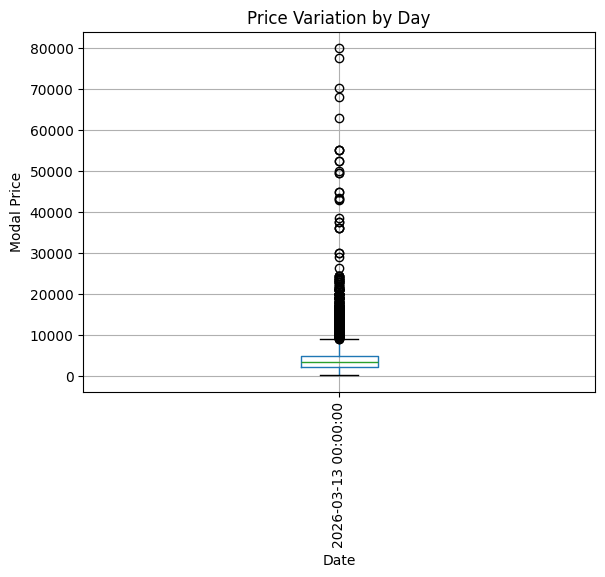

In [29]:
plt.figure(figsize=(12,6))

df.boxplot(column="Modal_x0020_Price", by="Arrival_Date", rot=90)

plt.title("Price Variation by Day")
plt.suptitle("")
plt.xlabel("Date")
plt.ylabel("Modal Price")

plt.show()

Interpretation

The boxplot illustrates the distribution of modal prices for crops across different arrival dates. Each box represents the spread of prices recorded on a specific day, including the median price and the variability within that day's transactions. Wider boxes or longer whiskers indicate greater price fluctuations, while narrower boxes suggest more stable prices. This visualization helps identify days when market prices were more volatile and highlights potential outliers in the price data.

Question 8
Do some crops show more price variability?

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2361 (\N{DEVANAGARI LETTER HA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2368 (\N{DEVANAGARI VOWEL SIGN II}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2350 (\N{DEVANAGARI LETTER MA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib

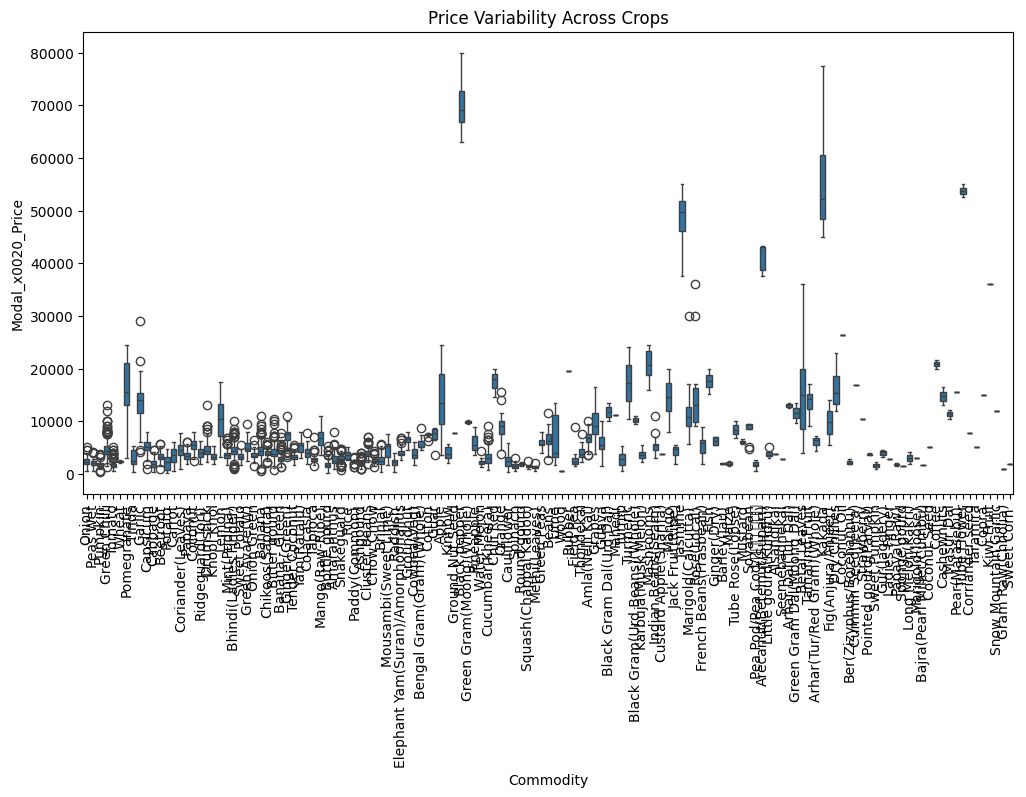

In [31]:
plt.figure(figsize=(12,6))
sns.boxplot(x="Commodity", y="Modal_x0020_Price", data=df)
plt.xticks(rotation=90)
plt.title("Price Variability Across Crops")
plt.show()

Interpretation

The box plot shows price spread for different crops.
Crops with larger boxes or longer whiskers have greater price fluctuations.

Question 9
What features correlate most with price?

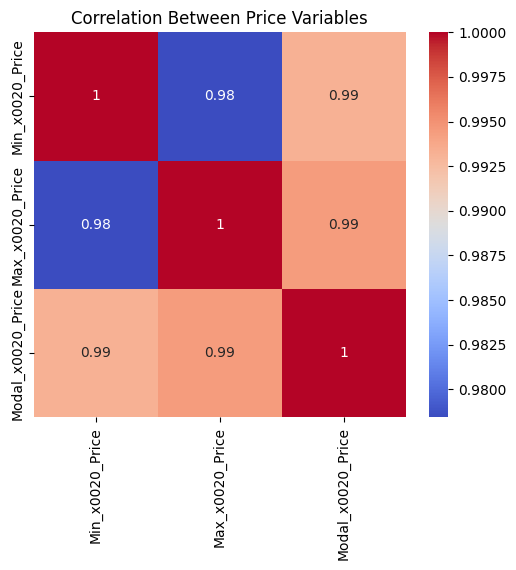

In [34]:
corr = df[["Min_x0020_Price","Max_x0020_Price","Modal_x0020_Price"]].corr()

plt.figure(figsize=(6,5))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Between Price Variables")

plt.show()

Interpretation

The heatmap shows that minimum and maximum prices are strongly correlated with modal price, making them useful predictors for machine learning models.

Question 10
Which commodities appear most frequently in the dataset?

This helps understand which crops dominate the dataset.

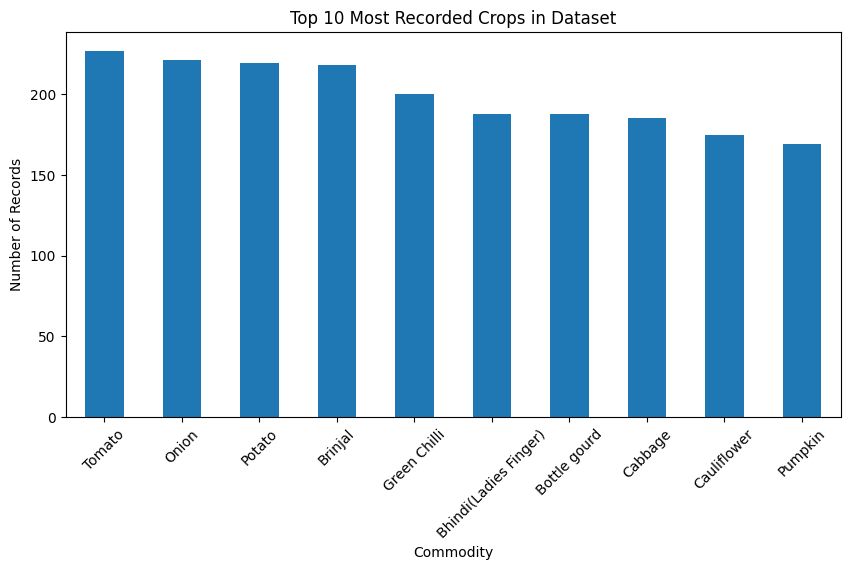

In [35]:
plt.figure(figsize=(10,5))

top_crops = df["Commodity"].value_counts().head(10)

top_crops.plot(kind="bar")

plt.title("Top 10 Most Recorded Crops in Dataset")
plt.xlabel("Commodity")
plt.ylabel("Number of Records")

plt.xticks(rotation=45)

plt.show()

Interpretation

The bar chart shows the crops that appear most frequently in the dataset. A higher number of records for a particular crop indicates that it is more commonly traded or monitored in the markets included in the dataset. Understanding which crops dominate the dataset helps identify where most of the market activity occurs and ensures that the prediction model is trained on crops with sufficient data.